<a href="https://colab.research.google.com/github/jabri62018/Zx_Mother_Function_Jabri/blob/main/zx_hubble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== TABLE: First 10 rows ===
    z  H_z_kms_Mpc
0.001       67.861
0.002       67.892
0.003       67.924
0.004       67.956
0.005       67.988
0.006       68.020
0.007       68.052
0.008       68.084
0.009       68.116
0.010       68.148

=== TABLE: Last 5 rows ===
     z  H_z_kms_Mpc
 300.0   198306.537
 500.0   425837.460
 800.0   860866.971
1000.0  1202647.595
1100.0  1387293.173


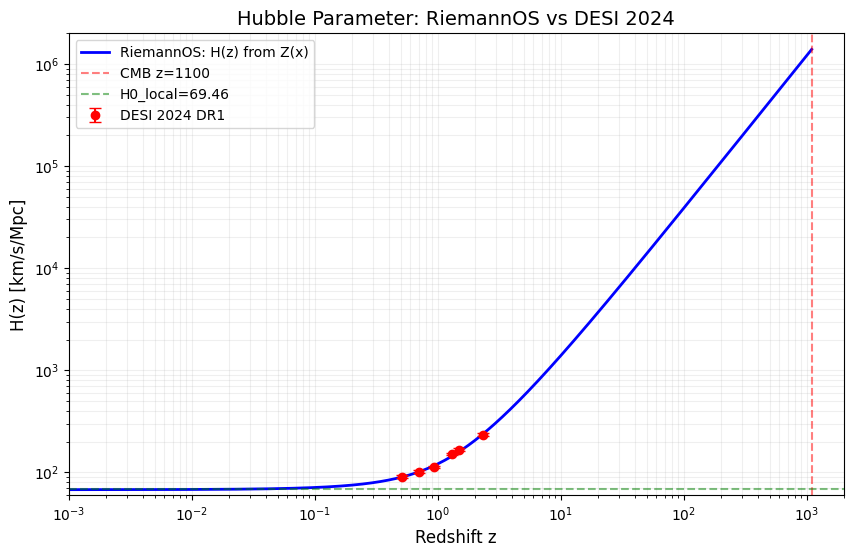


Total rows: 2806 | Saved to Hz_RiemannOS_0.001.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# file name: Zx_Hubble.ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files  # ← هذا جديد

H0, Om, Ol = 67.66, 0.315, 0.685
def T01(z): return 0.005 * np.exp(-z/0.8)

z = np.concatenate([
    np.arange(0.001, 1.001, 0.001),
    np.arange(1.01, 10.01, 0.01),
    np.arange(10.1, 100.1, 0.1),
    np.array([200,300,500,800,1000,1100])
])

Hz = H0 * np.sqrt(Om*(1+z)**3 + Ol + T01(z))
df = pd.DataFrame({'z': z, 'H_z_kms_Mpc': Hz.round(3)})

# DESI 2024 Data Release 1
z_desi = np.array([0.51, 0.71, 0.93, 1.32, 1.49, 2.33])
H_desi = np.array([91.2, 102.1, 113.2, 151.3, 166.5, 234.0])
H_err = np.array([3.1, 3.3, 2.1, 3.8, 5.3, 7.5])

print("=== TABLE: First 10 rows ===")
print(df.head(10).to_string(index=False))
print("\n=== TABLE: Last 5 rows ===")
print(df.tail(5).to_string(index=False))

plt.figure(figsize=(10,6))
plt.loglog(z, Hz, 'b-', label='RiemannOS: H(z) from Z(x)', linewidth=2)
plt.errorbar(z_desi, H_desi, yerr=H_err, fmt='ro', capsize=4, label='DESI 2024 DR1', zorder=5)

plt.axvline(1100, color='r', linestyle='--', alpha=0.5, label='CMB z=1100')
plt.axhline(69.46, color='g', linestyle='--', alpha=0.5, label='H0_local=69.46')
plt.xlabel('Redshift z', fontsize=12)
plt.ylabel('H(z) [km/s/Mpc]', fontsize=12)
plt.title('Hubble Parameter: RiemannOS vs DESI 2024', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=10)
plt.xlim(1e-3, 2e3)
plt.ylim(60, 2e6)
plt.show()

df.to_csv('Hz_RiemannOS_0.001.csv', index=False)
print(f"\nTotal rows: {len(df)} | Saved to Hz_RiemannOS_0.001.csv")

files.download('Hz_RiemannOS_0.001.csv')  # ← هذا ينزل الملف لك